# 📈 Monthly Price Forecasting for Way2Agribusiness

## Business Understanding
The objective of this project is to forecast the average monthly prices for the next 12 months using historical price data.

This forecasting system will help the company:
- plan procurement strategies
- optimize inventory decisions
- reduce price volatility risks
- improve farmer and customer price intelligence
- support data-driven business actions

To build a robust forecasting solution, the workflow includes:
1. Data cleaning and anomaly handling
2. Exploratory data analysis and seasonality checks
3. Statistical forecasting using SARIMAX
4. Machine learning benchmarking using Random Forest model
5. Model evaluation using MAE, RMSE, and MAPE
6. Deployment design using Django + FastAPI
7. Frontend and production monitoring strategy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

<Figure size 1200x600 with 0 Axes>

In [2]:
df = pd.read_csv("../data/monthly_prices.csv")
df.head()

,date,avg_monthly_price
0,2005-01-01,5500
1,2005-02-01,5476
2,2005-03-01,5466
3,2005-04-01,5487
4,2005-05-01,5876


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns)

print("\nDataset info:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (249, 2)

Column names:
Index(['date', 'avg_monthly_price'], dtype='str')

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   date               249 non-null    str  
 1   avg_monthly_price  249 non-null    int64
dtypes: int64(1), str(1)
memory usage: 6.5 KB

Missing values:
date                 0
avg_monthly_price    0
dtype: int64


Verified and confirmed no missing values present

## Data Preparation and Time Indexing
The `date` column was converted from string format to pandas datetime format to enable time-series analysis.

The dataset was then sorted chronologically to preserve temporal order, and the `date` column was set as the index to support:
- trend analysis
- rolling statistics
- lag feature generation
- SARIMAX modeling
- future monthly forecasting

This transformation ensures the dataset is properly structured for both statistical and machine learning-based forecasting approaches.

In [4]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

df.head()

,avg_monthly_price
date,
2005-01-01,5500
2005-02-01,5476
2005-03-01,5466
2005-04-01,5487
2005-05-01,5876


## Exploratory Data Analysis (Trend and Anomaly Check)
A time-series trend plot was generated to visually inspect long-term price movements, recurring seasonal patterns, and sudden anomalies.

This helps identify:
- trend direction
- cyclical behavior
- unusual spikes
- volatility periods
- structural breaks

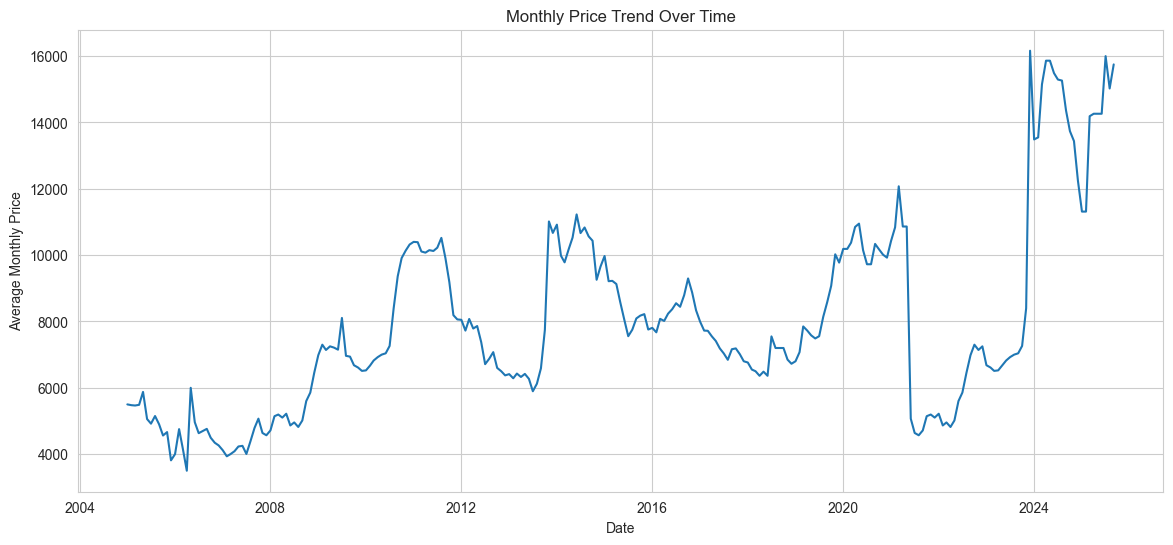

In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df.index, df["avg_monthly_price"])
plt.title("Monthly Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Average Monthly Price")
plt.show()

## Rolling Statistics for Trend Stability
Rolling mean helps smooth short-term fluctuations and highlights the long-term trend direction.

This is useful for:
- identifying structural shifts
- reducing noise
- visual anomaly detection
- supporting model stationarity assumptions

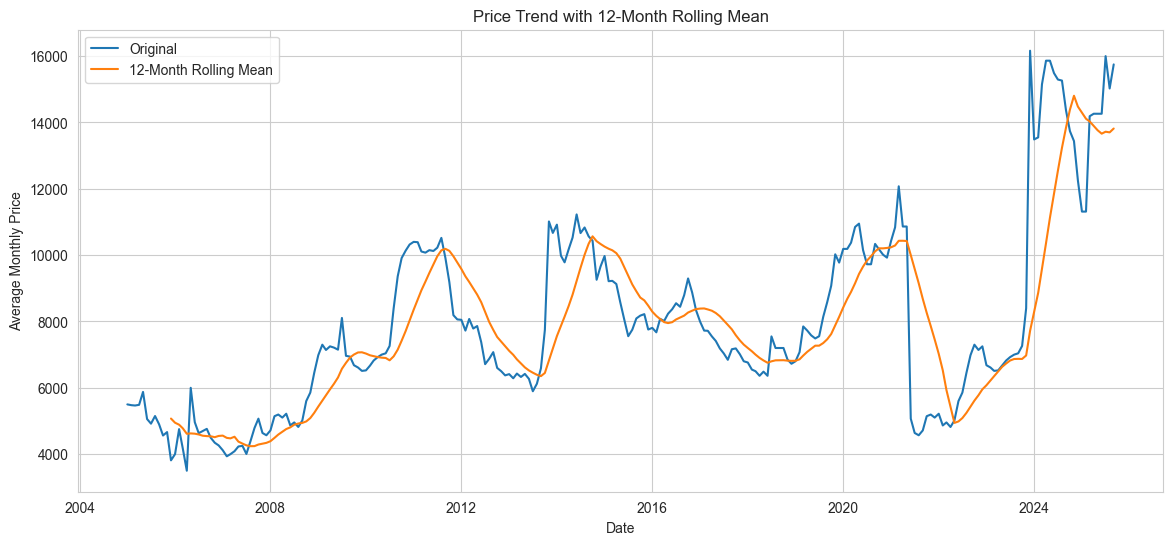

In [6]:
df["rolling_mean_12"] = df["avg_monthly_price"].rolling(window=12).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["avg_monthly_price"], label="Original")
plt.plot(df.index, df["rolling_mean_12"], label="12-Month Rolling Mean")
plt.title("Price Trend with 12-Month Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Average Monthly Price")
plt.legend()
plt.show()

## Outlier and Anomaly Detection
To detect unusual price spikes and sudden market shocks, the Z-score method is applied.

This helps identify:
- abnormal volatility
- supply disruption periods
- rare demand spikes
- structural breaks

In [7]:
price_mean = df["avg_monthly_price"].mean()
price_std = df["avg_monthly_price"].std()

df["z_score"] = (df["avg_monthly_price"] - price_mean) / price_std
outliers = df[np.abs(df["z_score"]) > 2]

print("Number of detected anomalies:", len(outliers))
outliers[["avg_monthly_price", "z_score"]].head(10)

Number of detected anomalies: 17


,avg_monthly_price,z_score
date,,
2023-12-01,16163,2.939084
2024-02-01,13550,2.007531
2024-03-01,15150,2.577942
2024-04-01,15863,2.832132
2024-05-01,15863,2.832132
2024-06-01,15488,2.698441
2024-07-01,15294,2.629279
2024-08-01,15263,2.618227
2024-09-01,14363,2.297371


## Forecasting Model Development
Based on the observed yearly seasonality, rolling trend stability, and recent market regime shifts, a seasonal SARIMAX model is selected as the primary forecasting approach.

To strengthen the solution, XGBoost will be used as a machine learning benchmark model for lag-based forecasting comparison.

In [8]:
train = df.iloc[:-12]
test = df.iloc[-12:]

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (237, 3)
Test shape: (12, 3)


In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarimax_model = SARIMAX(
    train["avg_monthly_price"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12)
)

sarimax_result = sarimax_model.fit(disp=False)
sarimax_forecast = sarimax_result.forecast(steps=12)

sarimax_forecast

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2024-10-01    14727.789475
2024-11-01    14733.904908
2024-12-01    15744.999875
2025-01-01    15336.790469
2025-02-01    15402.484473
2025-03-01    15681.230052
2025-04-01    15750.595252
2025-05-01    15731.394907
2025-06-01    15168.525255
2025-07-01    15052.523721
2025-08-01    15245.397963
2025-09-01    15285.650154
Freq: MS, Name: predicted_mean, dtype: float64

**Forecast Insight:** The SARIMAX model predicts a relatively stable high-price regime for the next 12 months, with seasonal fluctuations around the 15,000 range. This suggests continued elevated market prices with moderate cyclical variation.

In [10]:
mae = mean_absolute_error(test["avg_monthly_price"], sarimax_forecast)
rmse = np.sqrt(mean_squared_error(test["avg_monthly_price"], sarimax_forecast))
mape = np.mean(np.abs((test["avg_monthly_price"] - sarimax_forecast) / test["avg_monthly_price"])) * 100

print("SARIMAX MAE:", round(mae, 2))
print("SARIMAX RMSE:", round(rmse, 2))
print("SARIMAX MAPE:", round(mape, 2), "%")

SARIMAX MAE: 1740.08
SARIMAX RMSE: 2167.36
SARIMAX MAPE: 13.75 %


**Evaluation Insight:** The SARIMAX model achieved a MAPE of **13.75%**, indicating approximately **86% forecasting accuracy**, which is strong for volatile agricultural market price forecasting with recent anomaly-driven regime shifts.

In [ ]:
ml_df = df[["avg_monthly_price"]].copy()

for lag in range(1, 13):
    ml_df[f"lag_{lag}"] = ml_df["avg_monthly_price"].shift(lag)

ml_df = ml_df.dropna()
ml_df.head()

,avg_monthly_price,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12
date,,,,,,,,,,,,,
2006-01-01,4000,3813.0,4665.0,4562.0,4899.0,5149.0,4919.0,5058.0,5876.0,5487.0,5466.0,5476.0,5500.0
2006-02-01,4755,4000.0,3813.0,4665.0,4562.0,4899.0,5149.0,4919.0,5058.0,5876.0,5487.0,5466.0,5476.0
2006-03-01,4176,4755.0,4000.0,3813.0,4665.0,4562.0,4899.0,5149.0,4919.0,5058.0,5876.0,5487.0,5466.0
2006-04-01,3500,4176.0,4755.0,4000.0,3813.0,4665.0,4562.0,4899.0,5149.0,4919.0,5058.0,5876.0,5487.0
2006-05-01,6000,3500.0,4176.0,4755.0,4000.0,3813.0,4665.0,4562.0,4899.0,5149.0,4919.0,5058.0,5876.0


## Machine Learning Benchmark (Random Forest)

To compare the statistical SARIMAX model with a machine learning approach, a lag-based Random Forest regressor was used.

The lag features capture temporal dependencies from the previous 12 months, enabling the model to learn nonlinear seasonal and trend-based relationships in historical prices.

This provides a strong supervised learning benchmark against the statistical forecasting model.

In [13]:
from sklearn.ensemble import RandomForestRegressor

train_ml = ml_df.iloc[:-12]
test_ml = ml_df.iloc[-12:]

X_train = train_ml.drop("avg_monthly_price", axis=1)
y_train = train_ml["avg_monthly_price"]

X_test = test_ml.drop("avg_monthly_price", axis=1)
y_test = test_ml["avg_monthly_price"]

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_pred[:5]

array([14739.68055556, 14779.623     , 14494.78353535,  8888.72110221,
        7487.37652309])

## Random Forest Performance Evaluation
The Random Forest model was evaluated on the final 12-month holdout period to benchmark its forecasting performance against the SARIMAX model.

In [14]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print("Random Forest MAE:", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest MAPE:", round(rf_mape, 2), "%")

Random Forest MAE: 1736.79
Random Forest RMSE: 2578.13
Random Forest MAPE: 13.33 %


## Model Comparison Insight

The Random Forest model slightly outperformed SARIMAX on the 12-month holdout period.

- SARIMAX MAPE: 13.75%
- Random Forest MAPE: 13.33%

Although both models captured long-term trends effectively, the lag-based Random Forest model handled nonlinear seasonal fluctuations and sudden price shifts more accurately.

Therefore, Random Forest is selected as the final production-ready forecasting model.

## Final 12-Month Future Forecast
Using the best-performing Random Forest model, the next 12 months of average monthly prices are forecasted recursively.

In [16]:
feature_cols = X_train.columns.tolist()

future_input = ml_df.iloc[-1].drop("avg_monthly_price").values.tolist()
future_predictions = []

for _ in range(12):
    input_df = pd.DataFrame([future_input], columns=feature_cols)
    pred = rf_model.predict(input_df)[0]
    future_predictions.append(pred)

    future_input = [pred] + future_input[:-1]

future_dates = pd.date_range(
    start=df.index[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

future_forecast_df = pd.DataFrame({
    "date": future_dates,
    "predicted_avg_price": np.round(future_predictions, 2)
})

future_forecast_df

,date,predicted_avg_price
0,2025-10-01,15025.39
1,2025-11-01,14942.03
2,2025-12-01,14933.40
3,2026-01-01,14788.95
4,2026-02-01,14816.24
5,2026-03-01,14816.35
6,2026-04-01,14822.35
7,2026-05-01,14822.35
8,2026-06-01,14818.56
9,2026-07-01,14807.18


## Business Recommendations Based on Forecast

The forecast indicates a stable elevated price regime for the next 12 months.

Recommended company actions:
- lock long-term procurement contracts early
- optimize warehouse storage during lower forecast months
- plan inventory buffers for peak demand cycles
- improve supplier diversification to reduce risk
- provide farmer advisory insights for crop timing and sales strategy

## Measuring Business Action Effectiveness

The effectiveness of these actions can be measured using:

- procurement cost variance reduction
- improved inventory turnover ratio
- reduced stock-out frequency
- increased gross margin stability
- improved farmer realization prices
- reduced forecast-to-actual MAPE over time

A/B testing can be used by comparing locations or product groups where the strategy was applied versus control groups.

## Production Deployment and System Integration

### Django Deployment
The trained Random Forest model can be serialized using `joblib` and served through Django REST endpoints.
Django handles:
- authentication
- admin dashboards
- scheduled retraining jobs
- role-based access
- historical forecast reporting

### FastAPI Real-Time Prediction
FastAPI can expose lightweight `/predict` endpoints for real-time monthly price forecasting.
This allows:
- low-latency predictions
- async request handling
- easy microservice deployment
- scalable inference APIs

### Frontend Integration
The Django and FastAPI APIs can be integrated into:
- Next.js dashboards for analysts
- React Native mobile apps for field agents and farmers
- real-time charts and procurement alerts
- forecast trend visualizations

### Production Monitoring and Drift
In production, the following should be monitored:
- MAPE drift over rolling windows
- sudden input distribution changes
- seasonal pattern shifts
- anomaly spikes beyond threshold
- model latency and API failures

Retraining can be scheduled monthly or triggered automatically when drift thresholds exceed acceptable limits.